Dataset Link: https://github.com/mritunjoychk17/Dengue-Prediction-in-Bangladesh-Using-Machine-Learning/blob/main/CBC%20Report.csv

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("cbc_1500.csv")
df.head()

,Gender,Age,Haemoglobin,ESR,WBC,Neutrophil,Lymphocyte,Monocyte,Eosinophil,Basophil,RBC,Platelets,Result
0,Female,50,10.3,66,5.38,45,37,5,2,0,3.74,23,Positive
1,Female,78,9.6,36,3.47,55,43,10,0,0,4.41,95,Positive
2,Male,15,9.4,40,5.05,45,42,6,2,1,3.70,24,Positive
3,Male,57,11.6,25,4.09,66,38,5,1,1,4.42,88,Positive
4,Male,27,10.0,42,4.50,64,31,11,3,1,4.90,95,Positive


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gender       1500 non-null   object 
 1   Age          1500 non-null   int64  
 2   Haemoglobin  1500 non-null   float64
 3   ESR          1500 non-null   int64  
 4   WBC          1500 non-null   float64
 5   Neutrophil   1500 non-null   int64  
 6   Lymphocyte   1500 non-null   int64  
 7   Monocyte     1500 non-null   int64  
 8   Eosinophil   1500 non-null   int64  
 9   Basophil     1500 non-null   int64  
 10  RBC          1500 non-null   float64
 11  Platelets    1500 non-null   int64  
 12  Result       1500 non-null   object 
dtypes: float64(3), int64(8), object(2)
memory usage: 152.5+ KB


In [4]:
df.isnull().sum()

Gender         0
Age            0
Haemoglobin    0
ESR            0
WBC            0
Neutrophil     0
Lymphocyte     0
Monocyte       0
Eosinophil     0
Basophil       0
RBC            0
Platelets      0
Result         0
dtype: int64

In [5]:
df.describe()

,Age,Haemoglobin,ESR,WBC,Neutrophil,Lymphocyte,Monocyte,Eosinophil,Basophil,RBC,Platelets
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,41.762667,12.228067,36.107333,5.211807,57.217333,31.841333,6.936667,1.787333,0.494667,4.652773,137.013333
std,21.739428,1.671052,18.682519,2.119008,8.918621,9.068056,2.266881,1.330396,0.500138,0.540722,111.245726
min,5.000000,7.100000,5.000000,0.410000,40.000000,15.000000,3.000000,0.000000,0.000000,2.870000,10.000000
25%,22.750000,11.100000,20.000000,3.600000,51.000000,24.000000,5.000000,1.000000,0.000000,4.290000,52.000000
50%,42.000000,12.250000,35.000000,4.800000,58.000000,32.000000,7.000000,2.000000,0.000000,4.670000,95.000000
75%,61.000000,13.400000,52.000000,6.822500,64.250000,39.000000,9.000000,3.000000,1.000000,5.030000,223.000000
max,79.000000,17.200000,69.000000,12.240000,74.000000,49.000000,11.000000,4.000000,1.000000,6.130000,399.000000


In [6]:
print(df["Result"].value_counts())

Result
Positive    990
Negative    510
Name: count, dtype: int64


In [7]:
print(df["Result"].value_counts(normalize=True) * 100)

Result
Positive    66.0
Negative    34.0
Name: proportion, dtype: float64


In [8]:
class_counts = df["Result"].value_counts()
class_percent = df["Result"].value_counts(normalize=True) * 100

for label in class_counts.index:
    print(f"{label}: {class_counts[label]} samples ({class_percent[label]:.2f}%)")

Positive: 990 samples (66.00%)
Negative: 510 samples (34.00%)


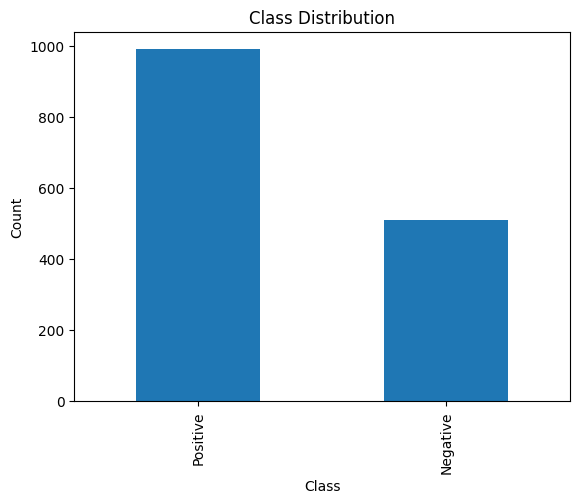

In [9]:
import matplotlib.pyplot as plt

df["Result"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
df_encoded = df.copy()
label_mappings = {}

In [12]:
for col in df_encoded.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    
    # Store mapping
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Print mappings
for col, mapping in label_mappings.items():
    print(f"\nColumn: {col}")
    for k, v in mapping.items():
        print(f"{k} -> {v}")


Column: Gender
Female -> 0
Male -> 1

Column: Result
Negative -> 0
Positive -> 1


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
# Separate features and target
X = df_encoded.drop("Result", axis=1)
y = df_encoded["Result"]

In [15]:
X

,Gender,Age,Haemoglobin,ESR,WBC,Neutrophil,Lymphocyte,Monocyte,Eosinophil,Basophil,RBC,Platelets
0,0,50,10.3,66,5.38,45,37,5,2,0,3.74,23
1,0,78,9.6,36,3.47,55,43,10,0,0,4.41,95
2,1,15,9.4,40,5.05,45,42,6,2,1,3.70,24
3,1,57,11.6,25,4.09,66,38,5,1,1,4.42,88
4,1,27,10.0,42,4.50,64,31,11,3,1,4.90,95
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0,7,15.9,19,5.82,52,35,3,1,0,4.55,217
1496,1,79,10.7,65,3.50,69,48,6,3,1,4.88,112
1497,1,51,15.9,12,7.00,58,22,5,0,1,4.44,246
1498,0,40,10.9,30,2.92,56,40,10,1,1,4.32,119


In [16]:
# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [17]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1200
Testing samples: 300


In [18]:
test_df = X_test.copy()
test_df["Result"] = y_test

test_df.to_csv("cbc_test_data.csv", index=False)
print("Test data saved successfully as cbc_test_data.csv")

Test data saved successfully as cbc_test_data.csv


In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed.")

Scaling completed.


In [21]:
# Reshape to 3D (samples, timesteps, 1)
X_train_rnn = X_train_scaled.reshape(X_train_scaled.shape[0],X_train_scaled.shape[1],1)
X_test_rnn = X_test_scaled.reshape(X_test_scaled.shape[0],X_test_scaled.shape[1],1)

print("Reshaping completed.")
print("RNN Input Shape:", X_train_rnn.shape)

Reshaping completed.
RNN Input Shape: (1200, 12, 1)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import numpy as np

In [23]:
input_layer = Input(shape=(X_train_rnn.shape[1], 1))

x = Bidirectional(LSTM(64, return_sequences=False))(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.0005),loss='binary_crossentropy',metrics=['accuracy'])

In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,465 (150.25 KB)

 Trainable params: 38,209 (149.25 KB)

 Non-trainable params: 256 (1.00 KB)

In [25]:
early_stop = EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

In [26]:
history = model.fit(X_train_rnn,y_train,epochs=100,batch_size=16,validation_split=0.2,callbacks=[early_stop],verbose=1)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8031 - loss: 0.4661 - val_accuracy: 0.8375 - val_loss: 0.6080
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9292 - loss: 0.2175 - val_accuracy: 0.9000 - val_loss: 0.5239
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9563 - loss: 0.1354 - val_accuracy: 0.9375 - val_loss: 0.4067
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9625 - loss: 0.1175 - val_accuracy: 0.9583 - val_loss: 0.3015
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9792 - loss: 0.0775 - val_accuracy: 0.9958 - val_loss: 0.1998
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9792 - loss: 0.0781 - val_accuracy: 0.9958 - val_loss: 0.1179
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9812 - loss: 0.0649 - val_accuracy: 1.0000 - val_loss: 0.0672
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9729 - loss: 0.0635 - val_accuracy: 1.0000 - v

In [27]:
loss, test_accuracy = model.evaluate(X_test_rnn, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 99.33%


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

In [29]:
y_pred_prob = model.predict(X_test_rnn)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       102
           1       0.99      1.00      0.99       198

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [30]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[100   2]
 [  0 198]]


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

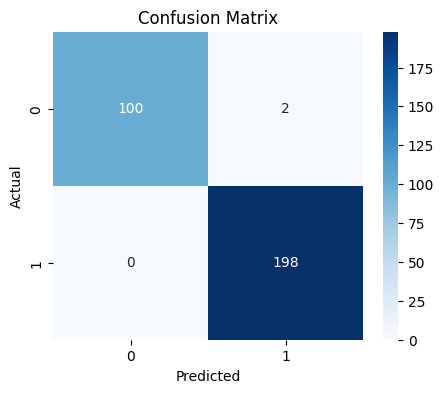

In [32]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
from sklearn.metrics import roc_curve, auc

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
ROC-AUC Score: 1.0000


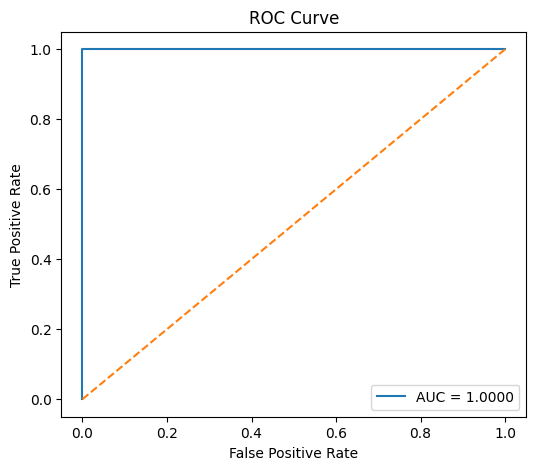

In [34]:
# Get predicted probabilities
y_pred_prob = model.predict(X_test_rnn)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [35]:
model.save("bilstm_dengue_model.h5")
print("Model saved successfully as bilstm_dengue_model.h5")

Model saved successfully as bilstm_dengue_model.h5


In [36]:
model.save("bilstm_dengue_model.keras")
print("Model saved successfully as bilstm_dengue_model.keras")

Model saved successfully as bilstm_dengue_model.keras


In [37]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']